In [1]:
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

tqdm.pandas()

project_id = "dh-global-sales-data-dev"

/home/jupyter/vendor_matching_exp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 0. Data tests

## 0.1 Menu extraction data tests

In [ ]:
"""
CREATE OR REPLACE TABLE dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_FP_MM AS
  select 
  b.lead_id as left_lead_id, f.left_name, f.left_name_local, f.left_street, f.left_lat, f.left_lng, f.left_phone_number,
  c.lead_id as right_lead_id, f.right_name, f.right_name_local, f.right_street, f.right_lat, f.right_lng, f.right_phone_number,
  a.predicted_label, a.prob,
  from `dh-global-sales-data.leadgen_sf_match_vertex_raw.matched_FP_MM` a
  left join `dh-global-sales-data.leadgen_sf_match_vertex_raw.candidates_FP_MM` f on a.left_row_id = f.left_row_id and a.right_row_id = f.right_row_id
  left join `dh-global-sales-data.leadgen_cl.vendor_complete` b on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.left_row_id) = b.lead_id and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id) = b.lead_source and (b.country_iso ="MM" or b.global_entity_id = 'FP_MM')
  left join `dh-global-sales-data.leadgen_cl.vendor_complete` c on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.right_row_id) = c.lead_id and (b.country_iso ="MM" or b.global_entity_id = 'FP_MM')
  where 
  (a.prob >= 0.95 and a.predicted_label = 1) or (a.prob <= 0.05 and a.predicted_label = 0)
  and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id)='grab';

CREATE OR REPLACE TABLE dh-global-sales-data-dev.leadgen_temp.exp_left_menus_FP_MM AS
  select distinct b.left_lead_id as left_lead_id, a.item_name as left_menu_item_name
  from `dh-global-sales-data.leadgen_cl.menu_complete` a
  join dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_FP_MM b on a.lead_id = b.left_lead_id and a.country_iso = 'MM' and a.lead_provider = 'anakin' and a.lead_source = 'grab'
  where a.item_name is not null;

CREATE OR REPLACE TABLE dh-global-sales-data-dev.leadgen_temp.exp_right_menus_FP_MM AS
  select distinct b.right_lead_id as right_lead_id, a.item_name as right_menu_item_name
  from `dh-global-sales-data.leadgen_cl.menu_complete` a
  join `dh-global-sales-data.leadgen_cl.vendor_complete` c on a.lead_id = c.sf_vendor_id
  join dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_FP_MM b on c.lead_id = b.right_lead_id and a.country_iso = 'MM' and a.lead_provider = 'dwh'
  where a.item_name is not null
"""

In [34]:
matching_data_mm_query = """
SELECT * FROM dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_FP_MM
"""

df_matching_data_mm = pd.read_gbq(query=matching_data_mm_query, project_id = project_id, progress_bar_type = 'tqdm')

/var/tmp/ipykernel_4380/107159603.py:5: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_matching_data_mm = pd.read_gbq(query=matching_data_mm_query, project_id = project_id, progress_bar_type = 'tqdm')

KeyboardInterrupt



In [ ]:
left_menus_mm_query = """
SELECT * FROM dh-global-sales-data-dev.leadgen_temp.exp_left_menus_FP_MM
"""

df_left_menus_mm = pd.read_gbq(query=left_menus_mm_query, project_id = project_id, progress_bar_type = 'tqdm')

In [ ]:
right_menus_mm_query = """
SELECT * FROM dh-global-sales-data-dev.leadgen_temp.exp_right_menus_FP_MM
"""

df_right_menus_mm = pd.read_gbq(query=right_menus_mm_query, project_id = project_id, progress_bar_type = 'tqdm')

In [ ]:
df_left_menus_mm_grouped = df_left_menus_mm.groupby("left_lead_id")["left_menu_item_name"].apply(list).reset_index()

In [6]:
df_right_menus_mm_grouped = df_right_menus_mm.groupby("right_lead_id")["right_menu_item_name"].apply(list).reset_index()

In [7]:
df_right_menus_mm_grouped.head()

,right_lead_id,right_menu_item_name
0,453C10,"[chocolate oreo smoothies, chocolate smoothies..."
1,453C16,"[raw green tea kombucha, ginger lemon infused ..."
2,453C1N,"[chocolate smoothies, mango smoothies, latte, ..."
3,453C1O,"[chocolate oreo smoothies, chocolate smoothies..."
4,453C1R,"[signature ဝက်ဂုတ်သားကင်, chicken basil with r..."


## 0.2 Keyword extraction from menu data tests

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
import stopwordsiso as stopwords_iso
from langdetect import detect
from collections import Counter
import re
import string
import unicodedata

def clean_text(text):
    text = re.sub(rf"[{string.punctuation}]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.lower().strip()

def tokenize(text):
    return text.split(" ")

def get_combined_stopwords(lang):
    sw = set()
    if stopwords_iso.has_lang(lang):
        sw.update(stopwords_iso.stopwords(lang))
    sw.update(stopwords_iso.stopwords('en'))
    sw.update({'menu', 'special', 'dish', 'plate', 'served', 'bowl', 'signature'})
    return sw

def extract_vendor_keywords(menu_items, top_n=50, force_lang=None):
    if not menu_items:
        return []

    raw_text = " ".join(menu_items)
    lang = force_lang or detect(raw_text)

    stop_words = get_combined_stopwords(lang)
    cleaned_docs = [clean_text(item) for item in menu_items]

    try:
        vectorizer = TfidfVectorizer(
            stop_words=stop_words,
            max_features=1000,
            ngram_range=(1, 2),
        )
        tfidf_matrix = vectorizer.fit_transform(cleaned_docs)
        feature_array = vectorizer.get_feature_names_out()
        tfidf_scores = tfidf_matrix.sum(axis=0).A1
        top_indices = tfidf_scores.argsort()[::-1][:top_n]
        return [(feature_array[i], tfidf_scores[i]) for i in top_indices]
    except Exception:
        # Fallback to frequency
        counter = Counter()
        for doc in cleaned_docs:
            tokens = tokenize(doc)
            tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
            counter.update(tokens)
        keywords = [kw for kw, _ in counter.most_common(top_n)]
        return " ".join(keywords)

In [9]:
test_menu = df_left_menus_mm_grouped["left_menu_item_name"][13]
test_menu

['ကြက်ပေါင်ကြော်',
 'ice latte',
 'ပသျှူးထမင်းကြော်',
 'စပိန်ထမင်းကြော်',
 'နှင်းဆီအဆီချဖျော်ရည်',
 'passion fruit soda',
 'ပုလဲနို့လက်ဖက်ရှည်',
 'လက်ဖက်ရည်နွားနို့',
 'kiwi smoothies/yogurt',
 'mocha frappe',
 'café latte',
 'streawberry soda',
 'dirty bubble milk',
 'caramel latte frappe',
 'အီတလီခေါက်ဆွဲ  seafood ins spicy tomato sauce',
 'စံပါယ်စိမ်းနို့လက်ဖက်ရည်',
 'brown sugar ginger tea',
 'ကင်မ်ချီထမင်းကြော်',
 'ပျားသံပုရာဖျော်ရည်',
 'သကြားမဲနို့လက်ဖက်ရည်',
 'ယိုးဒယားထမင်းကြော်',
 'milk  hot /ice',
 'သခွားသီးထောင်း',
 'အမဲသားပေါင်းခေါက်ဆွဲ',
 'oolong လက်ဖက်စိမ်းရည်',
 'ရှားစောင်းလက်ဖက်ဖျော်ရည်',
 'ကြက်ကြော် burger  chicken',
 'coffee frappe',
 'ice rose latte',
 'စံပါယ်စိမ်းလက်ဖက်ရည်',
 'ham and egg burger',
 'café americano',
 'ice americano',
 'matcha latte  hot / ice',
 'ယိုးဒယားသင်္ဘောသီးထောင်း',
 'ပင်စိမ်းထမင်း',
 'ပျားလက်ဖက်စိမ်းရည်',
 'club sandwich',
 'oolong လက်ဖက်ရည်နွားနို့',
 'ice mocha',
 'tuna sandwich',
 'peach soda',
 'omeletထမင်းကြော်',
 'အမဲသားသုပ်',
 'fish bu

In [10]:
kws = extract_vendor_keywords(test_menu, force_lang="my")

In [32]:
kws

'ice latte soda coffee smoothies yogurt frappe အီတလီခေါက်ဆွဲ tea burger mocha café milk sauce hot rose fruit လက်ဖက်ရည်နွားနို့ caramel tomato brown sugar oolong လက်ဖက်စိမ်းရည် americano sandwich tuna ထမင်းကြော် ကြက်ပေါင်ကြော် ပသျှူးထမင်းကြော် စပိန်ထမင်းကြော် နှင်းဆီအဆီချဖျော်ရည် passion ပုလဲနို့လက်ဖက်ရှည် kiwi streawberry dirty bubble seafood ins spicy စံပါယ်စိမ်းနို့လက်ဖက်ရည် ginger ကင်မ်ချီထမင်းကြော် ပျားသံပုရာဖျော်ရည် သကြားမဲနို့လက်ဖက်ရည် ယိုးဒယားထမင်းကြော် သခွားသီးထောင်း အမဲသားပေါင်းခေါက်ဆွဲ ရှားစောင်းလက်ဖက်ဖျော်ရည်'

## 0.3 Putting data together test

In [15]:
df_left_menus_mm_grouped["left_keywords"] = df_left_menus_mm_grouped.progress_apply(lambda x: extract_vendor_keywords(x.left_menu_item_name, force_lang="my"), axis=1)

100%|██████████| 3854/3854 [00:03<00:00, 1068.16it/s]


In [16]:
df_right_menus_mm_grouped["right_keywords"] = df_right_menus_mm_grouped.progress_apply(lambda x: extract_vendor_keywords(x.right_menu_item_name, force_lang="my"), axis=1)

100%|██████████| 5917/5917 [00:06<00:00, 849.67it/s] 


In [18]:
df_matching_data_mm_merged_left_menus = df_matching_data_mm.merge(df_left_menus_mm_grouped, on="left_lead_id", how="inner")

In [22]:
df_matching_data_mm_merged_all_menus = df_matching_data_mm_merged_left_menus.merge(df_right_menus_mm_grouped, on="right_lead_id", how="inner")

In [25]:
df_matching_data_mm_merged_all_menus = df_matching_data_mm_merged_all_menus.drop(columns=["right_menu_item_name", "left_menu_item_name"])
df_matching_data_mm_merged_all_menus = df_matching_data_mm_merged_all_menus.rename(columns={"left_street":"left_address", "right_street":"right_address"})

In [6]:
import math

def compute_haversine(lat1, lon1, lat2, lon2) -> float:
    """
    Returns haversine distance in *km*
    """
    # Convert coordinates from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )
    c = 2 * math.asin(math.sqrt(a))

    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

In [28]:
df_matching_data_mm_merged_all_menus["haversine"] = df_matching_data_mm_merged_all_menus.progress_apply(lambda x: compute_haversine(x.left_lat, x.left_lng, x.right_lat, x.right_lng), axis=1)

100%|██████████| 71643/71643 [00:02<00:00, 34799.20it/s]


In [29]:
df_matching_data_mm_merged_all_menus.head()

,left_lead_id,left_name,left_name_local,left_address,left_lat,left_lng,left_phone_number,right_lead_id,right_name,right_name_local,right_address,right_lat,right_lng,right_phone_number,predicted_label,prob,left_keywords,right_keywords,haversine
0,9-C32FRUVJEA42GX,omuk,omuk,null,16.7824,94.7307,None,HWZI5H,golden duck terminated,rebhaile: caa:phycun terminated,zeyawaddy 1 street house no 133 pathein,16.769214,94.729853,+9595200631,0,0.007727,chili vegetable fishcake kimchi rice tteokbokk...,salad pounded garlic oil noodle chicken rice e...,1.468975
1,9-C64GT64BBAVUT6,1 one,1 one,null,16.8758,96.0508,None,HZR4NV,latt sone drink hlaingtharyar,latt sone drink hlaingtharyar,no2 a kyan sit min housing estate hlaingtharya...,16.880033,96.062636,+959401620778,0,0.018219,blue durian pineapple သီးစုံ ဇီးကျောက်ကျော ice...,salad rice thai style fried noodle soup chicke...,1.344494
2,9-C6L3EAVZNNLHHE,lotteria,lotteria,null,16.8759,96.0511,None,HRZ00R,tea leaf,tea leaf,building 4 in front of the remaining sitmin ho...,16.879971,96.064162,+959954259945,0,0.005535,chicken burger shake cheesy set pack fried ric...,juice soda tea milkshake milk strawberry mango...,1.461749
3,9-C2JVNBV2GE42N2,nilar biryani,nilar biryani,null,16.8735,96.0514,None,HWNVS4,nilar biryani hlaing thar yar,niilaa dnpek liungsaayaa,building 381 b sein pan myaing street 7th ward...,16.873556,96.051448,+959977816131,1,0.977063,chicken biryani curry liver mutton ice cream r...,biryani chicken ice cream yogurt mutton cola c...,0.008030
4,9-C2JVNBV2GE42N2,nilar biryani,nilar biryani,null,16.8735,96.0514,None,HA9GQI,mingalar tea house hlaingtharyar,mingalar tea house liungsaayaa,happy food u pho hlaing rd near the intersecti...,16.876624,96.054415,+959760888895,0,0.011836,chicken biryani curry liver mutton ice cream r...,fried rice pork salad steamed egg fish soup ch...,0.472870


In [33]:
len(df_matching_data_mm_merged_all_menus)

71643

# 1. Global data preparation

In [ ]:
"""
CREATE OR REPLACE TABLE dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_PY_AR AS
  select 
  b.lead_id as left_lead_id, f.left_name, f.left_name_local, f.left_street, f.left_lat, f.left_lng, f.left_phone_number,
  c.lead_id as right_lead_id, f.right_name, f.right_name_local, f.right_street, f.right_lat, f.right_lng, f.right_phone_number,
  a.predicted_label, a.prob,
  from `dh-global-sales-data.leadgen_sf_match_vertex_raw.matched_PY_AR` a
  left join `dh-global-sales-data.leadgen_sf_match_vertex_raw.candidates_PY_AR` f on a.left_row_id = f.left_row_id and a.right_row_id = f.right_row_id
  left join `dh-global-sales-data.leadgen_cl.vendor_complete` b on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.left_row_id) = b.lead_id and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id) = b.lead_source and (b.country_iso ="AR" or b.global_entity_id = 'PY_AR')
  left join `dh-global-sales-data.leadgen_cl.vendor_complete` c on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.right_row_id) = c.lead_id and (b.country_iso ="AR" or b.global_entity_id = 'PY_AR')
  where 
  (a.prob >= 0.95 and a.predicted_label = 1) or (a.prob <= 0.05 and a.predicted_label = 0)
  and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id)='rappi'
  order by rand()
  limit 500000;

CREATE OR REPLACE TABLE dh-global-sales-data-dev.leadgen_temp.exp_left_menus_PY_AR AS
  select distinct b.left_lead_id as left_lead_id, a.item_name as left_menu_item_name
  from `dh-global-sales-data.leadgen_cl.menu_complete` a
  join dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_PY_AR b on a.lead_id = b.left_lead_id and a.country_iso = 'AR' and a.lead_provider = 'dataweave' and a.lead_source = 'rappi'
  where a.item_name is not null;

CREATE OR REPLACE TABLE dh-global-sales-data-dev.leadgen_temp.exp_right_menus_PY_AR AS
  select distinct b.right_lead_id as right_lead_id, a.item_name as right_menu_item_name
  from `dh-global-sales-data.leadgen_cl.menu_complete` a
  join `dh-global-sales-data.leadgen_cl.vendor_complete` c on a.lead_id = c.sf_vendor_id
  join dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_PY_AR b on c.lead_id = b.right_lead_id and a.country_iso = 'AR' and a.lead_provider = 'dwh'
  where a.item_name is not null
"""

In [ ]:
"""
CREATE OR REPLACE TABLE dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_PO_FI AS
  select 
  b.lead_id as left_lead_id, f.left_name, f.left_name_local, f.left_street, f.left_lat, f.left_lng, f.left_phone_number,
  c.lead_id as right_lead_id, f.right_name, f.right_name_local, f.right_street, f.right_lat, f.right_lng, f.right_phone_number,
  a.predicted_label, a.prob,
  from `dh-global-sales-data.leadgen_sf_match_vertex_raw.matched_PO_FI` a
  left join `dh-global-sales-data.leadgen_sf_match_vertex_raw.candidates_PO_FI` f on a.left_row_id = f.left_row_id and a.right_row_id = f.right_row_id
  left join `dh-global-sales-data.leadgen_cl.vendor_complete` b on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.left_row_id) = b.lead_id and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id) = b.lead_source and (b.country_iso ="FI" or b.global_entity_id = 'PO_FI')
  left join `dh-global-sales-data.leadgen_cl.vendor_complete` c on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.right_row_id) = c.lead_id and (b.country_iso ="FI" or b.global_entity_id = 'PO_FI')
  where 
  (a.prob >= 0.95 and a.predicted_label = 1) or (a.prob <= 0.05 and a.predicted_label = 0)
  and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id)='wolt';

CREATE OR REPLACE TABLE dh-global-sales-data-dev.leadgen_temp.exp_left_menus_PO_FI AS
  select distinct b.left_lead_id as left_lead_id, a.item_name as left_menu_item_name
  from `dh-global-sales-data.leadgen_cl.menu_complete` a
  join dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_PO_FI b on a.lead_id = b.left_lead_id and a.country_iso = 'FI' and a.lead_provider = 'dataweave' and a.lead_source = 'wolt'
  where a.item_name is not null;

CREATE OR REPLACE TABLE dh-global-sales-data-dev.leadgen_temp.exp_right_menus_PO_FI AS
  select distinct b.right_lead_id as right_lead_id, a.item_name as right_menu_item_name
  from `dh-global-sales-data.leadgen_cl.menu_complete` a
  join `dh-global-sales-data.leadgen_cl.vendor_complete` c on a.lead_id = c.sf_vendor_id
  join dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_PO_FI b on c.lead_id = b.right_lead_id and a.country_iso = 'FI' and a.lead_provider = 'dwh'
  where a.item_name is not null
"""

In [52]:
GED_TO_LANG_DICT = {"FP_MM": "my", "PY_AR": "es", "PO_FI": "fi"}

def prepare_menu_data(df_menus, group_by_col: str, menu_item_name_col: str, name_keywords_col: str, lang: str):
    df_menus_grouped = df_menus.groupby(group_by_col)[menu_item_name_col].apply(list).reset_index()
    df_menus_grouped[name_keywords_col] = df_menus_grouped.progress_apply(lambda x: extract_vendor_keywords(x[menu_item_name_col], force_lang=lang), axis=1)
    return df_menus_grouped

def prepare_training_data(global_entity_id: str):
    matching_data_query = f"SELECT * FROM dh-global-sales-data-dev.leadgen_temp.exp_matching_and_candgen_data_{global_entity_id}"
    df_matching_data = pd.read_gbq(query=matching_data_query, project_id = project_id, progress_bar_type = 'tqdm')

    left_menus_query = f"SELECT * FROM dh-global-sales-data-dev.leadgen_temp.exp_left_menus_{global_entity_id}"
    df_left_menus = pd.read_gbq(query=left_menus_query, project_id = project_id, progress_bar_type = 'tqdm')

    right_menus_query = f"SELECT * FROM dh-global-sales-data-dev.leadgen_temp.exp_right_menus_{global_entity_id}"
    df_right_menus = pd.read_gbq(query=right_menus_query, project_id = project_id, progress_bar_type = 'tqdm')

    df_left_menus_grouped = prepare_menu_data(df_left_menus, group_by_col="left_lead_id", menu_item_name_col="left_menu_item_name",
                                              name_keywords_col="left_keywords", lang=GED_TO_LANG_DICT[global_entity_id])
    df_right_menus_grouped = prepare_menu_data(df_right_menus, group_by_col="right_lead_id", menu_item_name_col="right_menu_item_name",
                                              name_keywords_col="right_keywords", lang=GED_TO_LANG_DICT[global_entity_id])

    df_matching_data_merged_left_menus = df_matching_data.merge(df_left_menus_grouped, on="left_lead_id", how="inner")
    df_matching_data_merged_all_menus = df_matching_data_merged_left_menus.merge(df_right_menus_grouped, on="right_lead_id", how="inner")

    df_matching_data_merged_all_menus = df_matching_data_merged_all_menus.drop(columns=["right_menu_item_name", "left_menu_item_name"])
    df_matching_data_merged_all_menus = df_matching_data_merged_all_menus.rename(columns={"left_street":"left_address", "right_street":"right_address"})

    df_matching_data_merged_all_menus["haversine"] = df_matching_data_mm_merged_all_menus.progress_apply(lambda x: compute_haversine(x.left_lat, x.left_lng, x.right_lat, x.right_lng), axis=1)

    return df_matching_data_merged_all_menus


def combine_and_balance_datasets(dfs, global_entity_id_list):
    assert len(dfs) == len(global_entity_id_list), "Each DataFrame must have a corresponding country name."

    # Tag each DataFrame with its country name
    tagged_dfs = []
    for df, geid in zip(dfs, global_entity_id_list):
        df = df.copy()
        df["global_entity_id"] = geid
        tagged_dfs.append(df)

    # Combine into one big DataFrame
    combined = pd.concat(tagged_dfs, ignore_index=True)

    # Balance: determine minimum count per (country, label)
    min_count = (
        combined.groupby(["global_entity_id", "predicted_label"])
        .size()
        .groupby(level=0)
        .min()
        .min()
    )

    # Sample min_count for each (country, label)
    balanced_parts = []
    for geid in global_entity_id_list:
        for label in [0, 1]:
            subset = combined[(combined["global_entity_id"] == geid) & (combined["predicted_label"] == label)]
            if len(subset) >= min_count:
                sampled = subset.sample(n=min_count, random_state=42)
                balanced_parts.append(sampled)

    # Return the balanced, combined DataFrame
    return pd.concat(balanced_parts).reset_index(drop=True)

def prepare_global_training_set(global_entity_id_list: list):
    dfs = []
    for geid in global_entity_id_list:
        print(f"Preparing {geid} data")
        dfs.append(prepare_training_data(global_entity_id=geid))
    print(f"Combine and balance global data")
    df_global_training_dataset = combine_and_balance_datasets(dfs, global_entity_id_list)
    return df_global_training_dataset

In [62]:
df_global_training_dataset = prepare_global_training_set(["FP_MM", "PO_FI", "PY_AR"])

Preparing FP_MM data


/var/tmp/ipykernel_3618/2200247042.py:10: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_matching_data = pd.read_gbq(query=matching_data_query, project_id = project_id, progress_bar_type = 'tqdm')



Downloading:   0%|          |
Downloading:   6%|▌         |
Downloading:  12%|█▏        |
Downloading:  17%|█▋        |
Downloading:  23%|██▎       |
Downloading:  29%|██▉       |
Downloading:  35%|███▍      |
Downloading:  41%|████      |
Downloading:  47%|████▋     |
Downloading:  52%|█████▏    |
Downloading:  58%|█████▊    |
Downloading:  64%|██████▍   |
Downloading:  70%|██████▉   |
Downloading:  76%|███████▌  |
Downloading:  82%|████████▏ |
Downloading:  87%|████████▋ |
Downloading:  93%|█████████▎|
Downloading:  99%|█████████▉|
Downloading: 100%|██████████|


/var/tmp/ipykernel_3618/2200247042.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_left_menus = pd.read_gbq(query=left_menus_query, project_id = project_id, progress_bar_type = 'tqdm')



Downloading:   0%|          |
Downloading:  71%|███████▏  |
Downloading: 100%|██████████|


...


Downloading:   0%|          |
Downloading:  21%|██▏       |
Downloading:  43%|████▎     |
Downloading:  64%|██████▍   |
Downloading:  85%|████████▌ |
Downloading: 100%|██████████|


/var/tmp/ipykernel_3618/2200247042.py:16: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_right_menus = pd.read_gbq(query=right_menus_query, project_id = project_id, progress_bar_type = 'tqdm')



Downloading:   0%|          |
Downloading:   3%|▎         |
Downloading:   6%|▌         |
Downloading:   8%|▊         |
Downloading:  11%|█         |
Downloading:  14%|█▍        |
Downloading:  17%|█▋        |
Downloading:  20%|█▉        |
Downloading:  22%|██▏       |
Downloading:  25%|██▌       |
Downloading:  28%|██▊       |
Downloading:  31%|███       |
Downloading:  34%|███▎      |
Downloading:  36%|███▋      |
Downloading:  39%|███▉      |
Downloading:  42%|████▏     |
Downloading:  45%|████▍     |
Downloading:  47%|████▋     |
Downloading:  50%|█████     |
Downloading:  53%|█████▎    |
Downloading:  56%|█████▌    |
Downloading:  59%|█████▊    |
Downloading:  61%|██████▏   |
Downloading:  64%|██████▍   |
Downloading:  67%|██████▋   |
Downloading:  70%|██████▉   |
Downloading:  73%|███████▎  |
Downloading:  75%|███████▌  |
Downloading:  78%|███████▊  |
Downloading:  81%|████████  |
Downloading:  84%|████████▍ |
Downloading:  87%|████████▋ |
Downloading:  89%|████████▉ |
Downloadi


100%|██████████| 18307/18307 [00:16<00:00, 1082.57it/s]

100%|██████████| 24913/24913 [01:07<00:00, 370.32it/s]

100%|██████████| 71643/71643 [00:01<00:00, 37195.43it/s]


Combine and balance global data


In [64]:
df_global_training_dataset.to_gbq("dh-global-sales-data-dev.leadgen_temp.exp_training_data_global_MM_FI_AR")

/var/tmp/ipykernel_3618/1852227115.py:1: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df_global_training_dataset.to_gbq("dh-global-sales-data-dev.leadgen_temp.exp_training_data_global_MM_FI_AR")

100%|██████████| 1/1 [00:00<00:00, 5159.05it/s]


# 2. Global model

In [2]:
global_training_dataset_query = """
SELECT * FROM dh-global-sales-data-dev.leadgen_temp.exp_training_data_global_MM_FI_AR
"""

df_global_training_dataset = pd.read_gbq(query=global_training_dataset_query, project_id = project_id, progress_bar_type = 'tqdm')

/var/tmp/ipykernel_36323/3193309134.py:5: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_global_training_dataset = pd.read_gbq(query=global_training_dataset_query, project_id = project_id, progress_bar_type = 'tqdm')


Downloading: 100%|██████████|


In [4]:
df_global_training_dataset[df_global_training_dataset["haversine"].isna()==True]

,left_lead_id,left_name,left_name_local,left_address,left_lat,left_lng,left_phone_number,right_lead_id,right_name,right_name_local,right_address,right_lat,right_lng,right_phone_number,predicted_label,prob,left_keywords,right_keywords,haversine,global_entity_id
20,f96574e9-4bce-463c-872b-d301b3b2bcd8,me re sirve fabrica de pizzas listas para horn...,me re sirve fabrica de pizzas listas para horn...,san martin 3000 q8300 neuquen argentina,-38.9550,-68.1004,None,HWDTWR,me re sirve - pizzas listas para hornear,me re sirve - pizzas listas para hornear,san martin 3000,-38.954825,-68.100910,+542296833681,1,0.991403,pizza aquarius cerveza patagonia rúcula sprite...,promo muzza 5l especial napolitana empanadas c...,NaN,PY_AR
25,8d304f15-fbcf-45fb-8060-9f89686df55e,citadeli neuquen,citadeli neuquen,sta fe 225 q8300 bge neuquen argentina,-38.9526,-68.0561,None,HKP80G,casa criolla neuquen,casa criolla neuquen,santa fe 244,-38.952464,-68.056342,+5492984590829,0,0.005454,500 empanada cocacola pizza azúcar tacc 354 47...,pizza empanada gaseosa milapizza comen 500 pan...,NaN,PY_AR
31,233715c4-b19a-44bb-96a2-fb3885ccb4a6,eletto,eletto,chrestia 510 neuquen neuquen argentina,-38.9494,-68.0733,None,4OVZMX,eletto helados - chrestia,eletto helados - chrestia,chrestia 510,-38.949449,-68.073295,+5492994643504,1,0.998081,postre x12 merengue helado postres oblea clási...,porciones postre 12 palito bombón chocolate me...,NaN,PY_AR
32,31c78957-fba4-49b9-95fc-6f7c11404715,borga empanadas - centro,borga empanadas - centro,antartida argentina 452 neuquen argentina,-38.9477,-68.0655,None,HRPC28,borga empanadas centro,borga empanadas centro,antartida argentina 452,-38.947697,-68.065536,+5492996039591,1,0.998819,lata empanada coca cola 500 310 docena empanad...,empanada empanadas coca cola cerveza bebida la...,NaN,PY_AR
33,a869c568-273a-4787-9141-7440913a53f3,mila distrito,mila distrito,av ramon 355 neuquen argentina,-38.9416,-68.0642,None,HKAM04,distrito mila,distrito mila,av dr ramon 355,-38.941828,-68.063830,+5491166686844 +5492996265181,1,0.993647,papas fritas mila huevo panceta alemana pepper...,milanesa guarnición guarnicion muzzarella nach...,NaN,PY_AR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2578,11330755-fc0e-4314-8376-adb89db30e18,croissant salta,croissant salta,huayratata,-24.8513,-65.4419,None,HKDXF1,croissant salta,croissant salta,urbanizacion la jorgelina calle huayratata esq...,-24.849830,-65.440484,+5493874791370,1,0.990884,tropicalmix lemonade lemon red,licuado unidad cafe leche pan arabe medialunas...,NaN,PY_AR
2580,e46db21d-09e7-41d2-8dc0-cac3c1bd747b,burger za centro sur,burger za centro sur,cordoba 970 salta argentina,-24.8024,-65.4094,None,HAWE9F,burgerza centro-sur,burgerza centro-sur,cordoba 970,-24.802384,-65.409417,+5493876235421,1,0.993697,hamburguesa parmezana doble papas burguer gold...,burger papas promo completo lomazo parmezanas ...,NaN,PY_AR
2592,b21b6cab-3638-4cee-9ca5-32a9917e58b4,rosmari helados artesanales cafe,rosmari helados artesanales cafe,pueyrredon 202 a4400 salta,-24.7875,-65.4066,None,45SVKQ,cafe martinez - salta belgrano restaurant,cafe martinez - salta belgrano restaurant,av belgrano 1297 esq simon bolivar,-24.786800,-65.420403,+543874219604,0,0.001942,helado bombón crema chantilly rosmari dulce ba...,tostado especial café latte queso jamón pollo ...,NaN,PY_AR
2604,98b9ba30-2876-451e-8798-3da51e177a8c,patio norte,patio norte,bartolome mitre 1211 salta argentina,-24.7746,-65.4096,None,HAEJVO,patio norte,patio norte,bartolome mitre 1211 salta capital,-24.774579,-65.409626,+5493468413687,1,0.998741,carne queso x6 pollo empanadas x12 x4 aquarius...,queso carne pollo x12 x6 emp x4 aquarius 500 x...,NaN,PY_AR


In [7]:
df_global_training_dataset["haversine"] = df_global_training_dataset.progress_apply(lambda x: compute_haversine(x.left_lat, x.left_lng, x.right_lat, x.right_lng), axis=1)

100%|██████████| 7842/7842 [00:00<00:00, 36024.57it/s]


In [10]:
df_global_training_dataset = df_global_training_dataset.dropna(subset=['haversine']).reset_index(drop=True)

In [118]:
df_global_training_dataset.head()

,left_lead_id,left_name,left_name_local,left_address,left_lat,left_lng,left_phone_number,right_lead_id,right_name,right_name_local,right_address,right_lat,right_lng,right_phone_number,predicted_label,prob,left_keywords,right_keywords,haversine,global_entity_id
0,21d5a469-cdaf-43b6-8156-b555b995adfe,super hot dog,super hot dog,av angel gallardo 1081 r8400 san carlos de bar...,-41.1386,-71.2951,None,HAYZRX,super hot dog,super hot dog,av angel gallardo 1081,-41.138461,-71.295147,+5492964494095,1,0.998323,500ml docena gaseosa super media agua budín ja...,pancho salchicha ahumada clásica maldito perro...,0.015971,PY_AR
1,f6a3322d-f236-402d-a957-6990d2c7ada9,mamuschka helados bariloche,mamuschka helados bariloche,mitre 216 san carlos de bariloche rio negro ar...,-41.1337,-71.3065,None,4CSMOC,solo empanadas bariloche 1,solo empanadas bariloche 1,av angel gallardo 1056,-41.138082,-71.295323,+5492944160441,0,0.003216,helado,pizza empanadas empanada grande muzzarella gas...,1.055244,PY_AR
2,6f85baa4-eb0d-43b4-b6ed-aa675c78e5d9,tante frida shopping,tante frida shopping,onelli 447 san carlos de bariloche rio negro a...,-41.1375,-71.2976,None,HKH6DE,tante frida shopping patagonia,tante frida shopping patagonia,onelli 447,-41.137465,-71.298070,+5492644428053,1,0.993170,helado unidades kilo patita espiral x2 corazon...,helado paleta palito garrita cono almendrado a...,0.039548,PY_AR
3,c706bca3-3bcf-4e6e-b3c1-146caaa163ff,la casa de la hamburguesa bariloche belgrano,la casa de la hamburguesa bariloche belgrano,24 de septiembre 210 r8400 san carlos de baril...,-41.1375,-71.3148,None,HWE1K7,la juana bariloche,la juana bariloche,dr juan javier neumeyer 34,-41.135728,-71.310638,+5492944671709,0,0.009611,500 hamburguesa aquarius papas cocacola vegeta...,hamburguesa pizza pollo guarnición papas litro...,0.400390,PY_AR
4,b35bf918-66eb-4e56-adc6-46d8aeec06b7,mcdonalds - bar,mcdonalds - bar,mitre 161 san carlos de bariloche rio negro ar...,-41.1338,-71.3076,None,HKHFIA,mcdonalds bar,mcdonalds bar,mitre 161,-41.133972,-71.307503,+541149668208,1,0.998376,doble mediano grande cuarto bacon tasty mccomb...,mediano doble grande cuarto queso mccombo gran...,0.020754,PY_AR


## 2.1 Architecture

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

class DualTowerBiEncoder(nn.Module):
    def __init__(self, model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", reduced_dim=256, tfidf_dim=100):
        super(DualTowerBiEncoder, self).__init__()
        self.semantic_encoder = SentenceTransformer(model_name)
        self.transformer = self.semantic_encoder._first_module().auto_model
        self.tokenizer = self.semantic_encoder.tokenizer

        # Unfreeze transformer parameters for fine-tuning
        for param in self.transformer.parameters():
            param.requires_grad = True

        hidden_size = self.transformer.config.hidden_size

        self.semantic_projection = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        self.lexical_projection = nn.Sequential(
            nn.Linear(tfidf_dim, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        self.final_projection = nn.Sequential(
            nn.Linear(2 * reduced_dim, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        # Classification head (input includes haversine distance)
        self.classifier = nn.Sequential(
            nn.Linear(reduced_dim + 2, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def encode_semantic(self, name_and_keywords):
        inputs = self.tokenizer(name_and_keywords, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {key: value.to(next(self.semantic_projection.parameters()).device) for key, value in inputs.items()}
        outputs = self.transformer(**inputs)
        text_embedding = outputs.last_hidden_state[:, 0, :]
        return self.semantic_projection(text_embedding)

    def encode_lexical(self, tfidf_vector):
        return self.lexical_projection(tfidf_vector)

    def forward(self, left_text, right_text, left_tfidf, right_tfidf, haversine_dists):
        left_semantic_embed = self.encode_semantic(left_text)
        right_semantic_embed = self.encode_semantic(right_text)

        left_lexical_embed = self.encode_lexical(left_tfidf)
        right_lexical_embed = self.encode_lexical(right_tfidf)

        left_final_embed = self.final_projection(torch.cat((left_semantic_embed, left_lexical_embed), dim=1))
        right_final_embed = self.final_projection(torch.cat((right_semantic_embed, right_lexical_embed), dim=1))

        # Normalize embeddings
        left_final_embed = F.normalize(left_final_embed, p=2, dim=1)
        right_final_embed = F.normalize(right_final_embed, p=2, dim=1)

        # Classification prediction
        abs_diff = torch.abs(left_final_embed - right_final_embed)
        cosine_sim = F.cosine_similarity(left_final_embed, right_final_embed).unsqueeze(1)
        combined = torch.cat((abs_diff, cosine_sim, haversine_dists.unsqueeze(1)), dim=1)
        match_prob = self.classifier(combined)

        return left_final_embed, right_final_embed, match_prob

In [67]:
# Dataset class
class VendorMatchingDataset(Dataset):
    def __init__(self, left_names, right_names, left_addresses, right_addresses, left_keywords, right_keywords, haversine_distances, labels):
        self.left_names = left_names
        self.right_names = right_names
        self.left_keywords = left_keywords
        self.right_keywords = right_keywords
        self.left_addresses = left_addresses
        self.right_addresses = right_addresses
        self.haversine_distances = haversine_distances
        self.labels = labels

        self.left_lexical_inputs = [f"{n} {a}" for n, a in zip(left_names, left_addresses)]
        self.right_lexical_inputs = [f"{n} {a}" for n, a in zip(right_names, right_addresses)]
        self.left_semantic_inputs = [f"{n} {' '.join(k)}" for n, k in zip(left_names, left_keywords)]
        self.right_semantic_inputs = [f"{n} {' '.join(k)}" for n, k in zip(right_names, right_keywords)]

        vectorizer = TfidfVectorizer(max_features=100)
        vectorizer.fit(self.left_lexical_inputs + self.right_lexical_inputs)
        self.vectorizer = vectorizer

        self.left_tfidf_vectors = [self.vectorizer.transform([txt]).toarray()[0] for txt in self.left_lexical_inputs]
        self.right_tfidf_vectors = [self.vectorizer.transform([txt]).toarray()[0] for txt in self.right_lexical_inputs]
        self.tfidf_dim = self.left_tfidf_vectors[0].shape[0]

    def __getitem__(self, idx):
        return (
            self.left_semantic_inputs[idx],
            self.right_semantic_inputs[idx],
            torch.tensor(self.left_tfidf_vectors[idx], dtype=torch.float32),
            torch.tensor(self.right_tfidf_vectors[idx], dtype=torch.float32),
            torch.tensor(np.log1p(self.haversine_distances[idx]) / np.log1p(100), dtype=torch.float32),
            self.labels[idx]
        )

    def __len__(self):
        return len(self.labels)

# Training function

import time
import gc

def train_with_split(model, dataset, train_ratio=0.8, epochs=10, batch_size=32, lr=1e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    test_size = total_size - train_size
    indices = list(range(total_size))
    np.random.shuffle(indices)

    train_indices = indices[:train_size]
    test_indices = indices[train_size:]

    pd.Series(train_indices).to_csv("train_indices.csv", index=False)
    pd.Series(test_indices).to_csv("test_indices.csv", index=False)

    train_set = torch.utils.data.Subset(dataset, train_indices)
    test_set = torch.utils.data.Subset(dataset, test_indices)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, num_workers=2, pin_memory=True)

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    loss_fn = nn.BCELoss()

    print(f"Training on: {device}")
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        val_loss = 0
        model.train()
        total_loss = 0

        for batch in train_loader:
            left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists, labels = batch
            left_tfidf = left_tfidf.to(device)
            right_tfidf = right_tfidf.to(device)
            haversine_dists = haversine_dists.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            _, _, match_probs = model(left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists)
            loss = loss_fn(match_probs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        model.eval()
        with torch.no_grad():
            for batch in test_loader:
                left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists, labels = batch
                left_tfidf = left_tfidf.to(device)
                right_tfidf = right_tfidf.to(device)
                haversine_dists = haversine_dists.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                _, _, match_probs = model(left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists)
                val_loss += loss_fn(match_probs, labels).item()

        avg_val_loss = val_loss / len(test_loader)
        preds = match_probs.cpu().numpy()
        true = labels.cpu().numpy()
        binary_preds = (preds >= 0.5).astype(int)

        f1 = f1_score(true, binary_preds)
        precision = precision_score(true, binary_preds)
        recall = recall_score(true, binary_preds)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f} - Val Loss: {avg_val_loss:.4f} - F1: {f1:.4f} - Precision: {precision:.4f} - Recall: {recall:.4f}")

    torch.save(model.state_dict(), "trained_model.pt")

    def save_predictions(loader, subset_name):
        model.eval()
        predictions = []
        with torch.no_grad():
            for batch in loader:
                left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists, labels = batch
                left_tfidf = left_tfidf.to(device)
                right_tfidf = right_tfidf.to(device)
                haversine_dists = haversine_dists.to(device)
                labels = labels.float().to(device)
                _, _, match_probs = model(left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists)
                for l, p in zip(labels.cpu().numpy(), match_probs.cpu().numpy()):
                    predictions.append((float(l), float(p)))
        df = pd.DataFrame(predictions, columns=["label", "predicted_probability"])
        df.to_csv(f"{subset_name}_predictions.csv", index=False)

    save_predictions(train_loader, "train")
    save_predictions(test_loader, "test")

    end_time = time.time()
    print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")
    gc.collect()
    torch.cuda.empty_cache()

    return model

In [14]:
def extract_vendor_embeddings(model, dataset, output_left="left_vendor_embeddings.csv", output_right="right_vendor_embeddings.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    left_embeddings = []
    right_embeddings = []

    with torch.no_grad():
        for i in range(len(dataset)):
            left_text, right_text, left_tfidf, right_tfidf, _, _ = dataset[i]

            # Process left (semantic + lexical)
            left_tfidf_tensor = left_tfidf.unsqueeze(0).to(device)
            left_text_batch = [left_text]
            left_semantic = model.encode_semantic(left_text_batch)
            left_lexical = model.encode_lexical(left_tfidf_tensor)
            left_combined = torch.cat((left_semantic, left_lexical), dim=1)
            left_embed = model.final_projection(left_combined)
            left_embed = F.normalize(left_embed, p=2, dim=1)
            left_embeddings.append(left_embed.squeeze(0).cpu().numpy())

            # Process right (semantic + lexical)
            right_tfidf_tensor = right_tfidf.unsqueeze(0).to(device)
            right_text_batch = [right_text]
            right_semantic = model.encode_semantic(right_text_batch)
            right_lexical = model.encode_lexical(right_tfidf_tensor)
            right_combined = torch.cat((right_semantic, right_lexical), dim=1)
            right_embed = model.final_projection(right_combined)
            right_embed = F.normalize(right_embed, p=2, dim=1)
            right_embeddings.append(right_embed.squeeze(0).cpu().numpy())

    # Save embeddings
    pd.DataFrame(left_embeddings).to_csv(output_left, index=False)
    pd.DataFrame(right_embeddings).to_csv(output_right, index=False)
    print(f"Saved {len(left_embeddings)} left and right vendor embeddings to {output_left} and {output_right}")

In [73]:
def generate_predictions(model, dataset, output_path="new_predictions.csv"):
    """
    Generates predictions using a trained model for each sample in a VendorMatchingDataset.

    Args:
        model: Trained DualTowerBiEncoder model
        dataset: VendorMatchingDataset instance
        output_path: CSV file to save predictions
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    predictions = []

    with torch.no_grad():
        for i in range(len(dataset)):
            left_text, right_text, left_tfidf, right_tfidf, haversine, label = dataset[i]

            left_tfidf = left_tfidf.unsqueeze(0).to(device)
            right_tfidf = right_tfidf.unsqueeze(0).to(device)
            haversine = haversine.unsqueeze(0).to(device)

            _, _, match_prob = model([left_text], [right_text], left_tfidf, right_tfidf, haversine)

            predictions.append({
                "left_text": left_text,
                "right_text": right_text,
                "predicted_probability": float(match_prob.item()),
                "haversine": float(haversine.item()),
                "label": float(label)
            })

    pd.DataFrame(predictions).to_csv(output_path, index=False)
    print(f"✅ Saved predictions to {output_path}")

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

def evaluate_predictions_from_csv(csv_path, threshold=0.5):
    """
    Evaluates model predictions saved in a CSV file.

    Parameters:
    - csv_path (str): path to the CSV file with columns ['label', 'predicted_probability']
    - threshold (float): threshold to convert probabilities to binary predictions

    Returns:
    - dict: evaluation metrics
    """
    df = pd.read_csv(csv_path)

    true_labels = df["label"]
    predicted_probs = df["predicted_probability"]
    predicted_labels = (predicted_probs >= threshold).astype(int)

    precision = precision_score(true_labels, predicted_labels)
    recall = recall_score(true_labels, predicted_labels)
    f1 = f1_score(true_labels, predicted_labels)
    roc_auc = roc_auc_score(true_labels, predicted_probs)

    print(f"📊 Evaluation from: {csv_path}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC AUC:   {roc_auc:.4f}")

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [112]:
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

def calculate_metrics_by_split_and_country(
    df: pd.DataFrame,
    predicted_proba_col: str = "predicted_probability",
    true_label_col: str = "predicted_label",
    country_col: str = "global_entity_id",
    split_type_col: str = "split_type", # New: Column for 'train'/'test' split
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Calculates F1-score, Precision, Recall, and AUC-score per unique country
    AND for the overall 'train' and 'test' splits.

    Args:
        df (pd.DataFrame): The input DataFrame containing predictions, true labels,
                           country IDs, and split type.
        predicted_proba_col (str): The name of the column containing predicted probabilities.
        true_label_col (str): The name of the column containing the true binary labels (0 or 1).
                               NOTE: Ensure this is your actual ground truth.
        country_col (str): The name of the column identifying the country or unique entity.
        split_type_col (str): The name of the column identifying the 'train' or 'test' split.
        threshold (float): The probability threshold to convert predicted probabilities into
                           binary predictions for F1, Precision, and Recall. Defaults to 0.5.

    Returns:
        pd.DataFrame: A DataFrame with 'global_entity_id' (or 'split_type' for overall scores)
                      and the calculated metrics (F1-Score, Precision, Recall, AUC-Score).
                      The 'global_entity_id' column will contain 'Train Overall' and 'Test Overall'
                      for the respective aggregate scores.
                      Returns an empty DataFrame if input is invalid or no data found.
    """
    required_cols = [predicted_proba_col, true_label_col, country_col, split_type_col]
    if not all(col in df.columns for col in required_cols):
        missing_cols = [col for col in required_cols if col not in df.columns]
        print(f"Error: Missing required columns in DataFrame: {missing_cols}")
        return pd.DataFrame()

    results = []

    # Ensure true labels are binary (0 or 1) and predictions are numeric
    df[true_label_col] = df[true_label_col].astype(int)
    df[predicted_proba_col] = pd.to_numeric(df[predicted_proba_col], errors='coerce')

    # Drop rows where predicted_proba_col became NaN due to coercion issues
    df_cleaned = df.dropna(subset=[predicted_proba_col]).copy() # Work on a copy

    if df_cleaned.empty:
        print("Warning: DataFrame is empty after dropping rows with invalid probabilities.")
        return pd.DataFrame()

    # --- Calculate Overall Metrics for Train and Test Splits ---
    for split in df_cleaned[split_type_col].unique():
        split_df = df_cleaned[df_cleaned[split_type_col] == split]

        if split_df.empty:
            continue

        y_true_split = split_df[true_label_col]
        y_proba_split = split_df[predicted_proba_col]
        y_pred_binary_split = (y_proba_split >= threshold).astype(int)

        metric_id = f"{split.capitalize()} Overall" # e.g., "Train Overall", "Test Overall"

        if len(y_true_split.unique()) < 2:
            print(f"Warning: Skipping '{metric_id}' due to insufficient classes (only {y_true_split.unique()} found).")
            results.append({
                country_col: metric_id,
                'F1-Score': pd.NA,
                'Precision': pd.NA,
                'Recall': pd.NA,
                'AUC-Score': pd.NA
            })
            continue

        try:
            f1 = f1_score(y_true_split, y_pred_binary_split)
            precision = precision_score(y_true_split, y_pred_binary_split)
            recall = recall_score(y_true_split, y_pred_binary_split)
            auc = roc_auc_score(y_true_split, y_proba_split)

            results.append({
                country_col: metric_id,
                'F1-Score': f1,
                'Precision': precision,
                'Recall': recall,
                'AUC-Score': auc
            })
        except ValueError as e:
            print(f"Warning: Could not calculate metrics for '{metric_id}'. Error: {e}")
            results.append({
                country_col: metric_id,
                'F1-Score': pd.NA,
                'Precision': pd.NA,
                'Recall': pd.NA,
                'AUC-Score': pd.NA
            })

    # --- Calculate Metrics Per Country (within each split) ---
    for split in df_cleaned[split_type_col].unique():
        for country in df_cleaned[df_cleaned[split_type_col] == split][country_col].unique():
            country_split_df = df_cleaned[(df_cleaned[country_col] == country) & (df_cleaned[split_type_col] == split)].copy()

            if country_split_df.empty:
                continue

            y_true = country_split_df[true_label_col]
            y_proba = country_split_df[predicted_proba_col]
            y_pred_binary = (y_proba >= threshold).astype(int)

            metric_id = f"{country} ({split.capitalize()})" # e.g., "USA (Train)"

            if len(y_true.unique()) < 2:
                # print(f"Warning: Skipping '{metric_id}' due to insufficient classes (only {y_true.unique()} found).")
                results.append({
                    country_col: metric_id,
                    'F1-Score': pd.NA,
                    'Precision': pd.NA,
                    'Recall': pd.NA,
                    'AUC-Score': pd.NA
                })
                continue

            try:
                f1 = f1_score(y_true, y_pred_binary)
                precision = precision_score(y_true, y_pred_binary)
                recall = recall_score(y_true, y_pred_binary)
                auc = roc_auc_score(y_true, y_proba)

                results.append({
                    country_col: metric_id,
                    'F1-Score': f1,
                    'Precision': precision,
                    'Recall': recall,
                    'AUC-Score': auc
                })
            except ValueError as e:
                print(f"Warning: Could not calculate metrics for '{metric_id}'. Error: {e}")
                results.append({
                    country_col: metric_id,
                    'F1-Score': pd.NA,
                    'Precision': pd.NA,
                    'Recall': pd.NA,
                    'AUC-Score': pd.NA
                })

    if not results:
        print("No metrics calculated. Check data or thresholds.")
        return pd.DataFrame()

    metrics_df = pd.DataFrame(results)
    return metrics_df.sort_values(by=country_col).reset_index(drop=True)

In [16]:
model = DualTowerBiEncoder()

In [17]:
training_dataset = df_global_training_dataset

In [18]:
# Prepare inputs for dataset
left_names = training_dataset["left_name"].tolist()
right_names = training_dataset["right_name"].tolist()
left_addresses = training_dataset["left_address"].tolist()
right_addresses = training_dataset["right_address"].tolist()
left_keywords = training_dataset["left_keywords"].tolist()
right_keywords = training_dataset["right_keywords"].tolist()
haversines = training_dataset["haversine"].tolist()
labels = training_dataset["predicted_label"].tolist()

# Create dataset
dataset = VendorMatchingDataset(
    left_names, right_names,
    left_addresses, right_addresses,
    left_keywords, right_keywords,
    haversines,
    labels
)

In [19]:
trained_model_global = train_with_split(model, dataset)

Training on: cuda


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch 1/10 - Train Loss: 0.6883 - Val Loss: 0.6764 - F1: 0.6111 - Precision: 0.5000 - Recall: 0.7857


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 2/10 - Train Loss: 0.6657 - Val Loss: 0.6566 - F1: 0.6667 - Precision: 0.5455 - Recall: 0.8571


...

Epoch 9/10 - Train Loss: 0.5231 - Val Loss: 0.5437 - F1: 0.8485 - Precision: 0.7368 - Recall: 1.0000


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 10/10 - Train Loss: 0.5026 - Val Loss: 0.5314 - F1: 0.8750 - Precision: 0.7778 - Recall: 1.0000


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/var/tmp/ipykernel_36323/274753656.py:132: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions.append((float(l), float(p)))
huggingface/tokenizers: The current process j

Total training time: 16.40 minutes


In [20]:
extract_vendor_embeddings(trained_model_global, dataset)

Saved 7837 left and right vendor embeddings to left_vendor_embeddings.csv and right_vendor_embeddings.csv


In [74]:
generate_predictions(trained_model_global, dataset)

✅ Saved predictions to new_predictions.csv


## 2.2 Evaluation

### 2.2.1 Classification metrics

In [21]:
train_predictions_path = 'train_predictions.csv'
test_predictions_path = 'test_predictions.csv'

In [22]:
evaluate_predictions_from_csv(train_predictions_path)

📊 Evaluation from: train_predictions.csv
  Precision: 0.8689
  Recall:    0.9443
  F1 Score:  0.9050
  ROC AUC:   0.9670


{'precision': 0.8688908399180568,
 'recall': 0.9443384223918575,
 'f1': 0.9050449626581314,
 'roc_auc': np.float64(0.966972417302799)}

In [23]:
evaluate_predictions_from_csv(test_predictions_path)

📊 Evaluation from: test_predictions.csv
  Precision: 0.8085
  Recall:    0.8803
  F1 Score:  0.8429
  ROC AUC:   0.9202


{'precision': 0.8085106382978723,
 'recall': 0.8803088803088803,
 'f1': 0.8428835489833642,
 'roc_auc': np.float64(0.9202042931499316)}

In [100]:
all_predictions = pd.read_csv("new_predictions.csv")
train_indices = pd.read_csv("train_indices.csv")
test_indices = pd.read_csv("test_indices.csv")
train_indices_list = train_indices["0"].unique().tolist()
test_indices_list = test_indices["0"].unique().tolist()

In [105]:
all_predictions["split_type"] = ""
all_predictions.loc[all_predictions.index.isin(train_indices_list), "split_type"] = "train"
all_predictions.loc[all_predictions.index.isin(test_indices_list), "split_type"] = "test"
df_global_training_dataset_with_preds = df_global_training_dataset.merge(all_predictions[["predicted_probability", "label", "split_type"]], how="left", left_index=True, right_index=True)

In [117]:
country_and_split_metrics = calculate_metrics_by_split_and_country(df_global_training_dataset_with_preds)
country_and_split_metrics

,global_entity_id,F1-Score,Precision,Recall,AUC-Score
0,FP_MM (Test),0.845735,0.859779,0.832143,0.915070
1,FP_MM (Train),0.910318,0.901624,0.919182,0.966009
2,PO_FI (Test),0.832392,0.767361,0.909465,0.931366
3,PO_FI (Train),0.895641,0.842585,0.955827,0.969992
4,PY_AR (Test),0.850277,0.801394,0.905512,0.923550
5,PY_AR (Train),0.909747,0.866724,0.957265,0.968996
6,Test Overall,0.842884,0.808511,0.880309,0.920203
7,Train Overall,0.905045,0.868891,0.944338,0.966972


### 2.2.2 Embedding evaluation

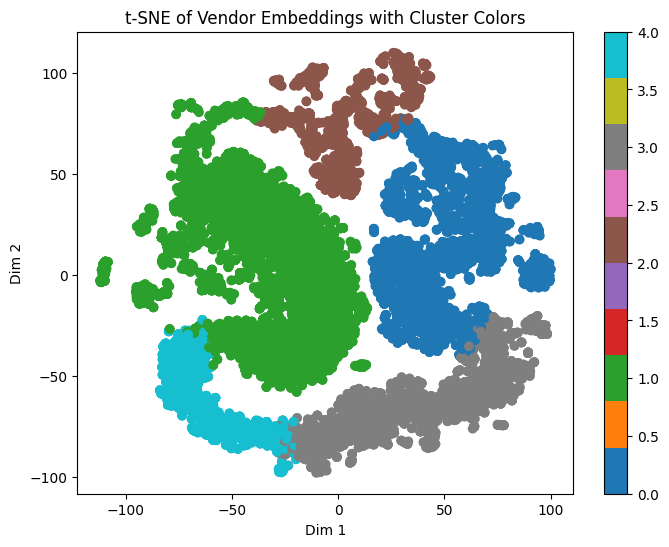

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load embeddings
left_embeddings_df = pd.read_csv("left_vendor_embeddings.csv")
right_embeddings_df = pd.read_csv("right_vendor_embeddings.csv")
embeddings_df = pd.concat([left_embeddings_df,right_embeddings_df])
embeddings = embeddings_df.values

# Run embedding clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_emb = kmeans.fit_predict(embeddings)

# Visualize
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels_emb, cmap='tab10')
plt.title("t-SNE of Vendor Embeddings with Cluster Colors")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(scatter)
plt.show()

In [34]:
from sklearn.metrics import silhouette_score

score = silhouette_score(embeddings, cluster_labels_emb)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.6126


In [35]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sims = cosine_similarity(embeddings)
vendor_idx = 0  # change this
similar_idxs = np.argsort(-sims[vendor_idx])[1:6]  # skip self

print(f"Top 5 neighbors for vendor {vendor_idx}: {similar_idxs}")

Top 5 neighbors for vendor 0: [ 7837  2918 11984 14764 10797]


In [41]:
left_cluster_labels = cluster_labels_emb[0:7837].tolist()
right_cluster_labels = cluster_labels_emb[7837:15674].tolist()

In [42]:
df_global_training_dataset["left_embedding_cluster_label"]=left_cluster_labels
df_global_training_dataset["right_embedding_cluster_label"]=right_cluster_labels

In [53]:
df_global_training_dataset[["left_name","left_address","left_keywords","left_embedding_cluster_label"]][0:1]

,left_name,left_address,left_keywords,left_embedding_cluster_label
5,super hot dog,av angel gallardo 1081 r8400 san carlos de bar...,500ml docena gaseosa super media agua budín ja...,3


In [62]:
df_global_training_dataset[["left_name","left_address","left_keywords","left_embedding_cluster_label"]][2918:2919]

,left_name,left_address,left_keywords,left_embedding_cluster_label
2923,fu fu hotpot mala xiang guo spicy noodles,null,noodles soup spicy balls chicken salad pork ma...,3


In [50]:
df_global_training_dataset[df_global_training_dataset["left_embedding_cluster_label"]==1][["left_name","left_address","left_keywords","left_embedding_cluster_label"]][0:50]

,left_name,left_address,left_keywords,left_embedding_cluster_label
10,rapanui bistro bariloche,mitre 202 san carlos de bariloche rio negro ar...,alfajor chocolate frambuesa jugo leche sandwic...,1
12,papagoonia,vice almte o connor 662 san carlos de bariloch...,hamburguesa pizza papas 500 sándwich aquarius ...,1
16,mostaza walmart neuquen,perticone 1255 neuquen argentina,combo mega doble cuarto papas xl bacon taste n...,1
18,citadeli neuquen,sta fe 225 q8300 bge neuquen argentina,500 empanada cocacola pizza azúcar tacc 354 47...,1
19,morelias oeste,general manuel belgrano 4123 neuquen argentina,papas combo cheese helado lata doble xxl ameri...,1
24,mostaza - perticone,eugenio perticone 215 neuquen argentina,combo mega doble cuarto bacon xl papas taste n...,1
25,citadeli neuquen,sta fe 225 q8300 bge neuquen argentina,500 empanada cocacola pizza azúcar tacc 354 47...,1
27,tienda de empanadas - neuquen,coronel godoy e 345 dsn neuquen argentina,empanada empanadas integral pepsi 500 docena p...,1
29,jalapeno neuquen,lastra 2400 neuquen argentina,500ml tabla aquarius pomelo cocacola mixta gra...,1
30,tercera docena empanadas,diag espana 115 q8300 neuquen neuquen argentina,empanada pizza jamón queso pizzeta 500ml carne...,1
